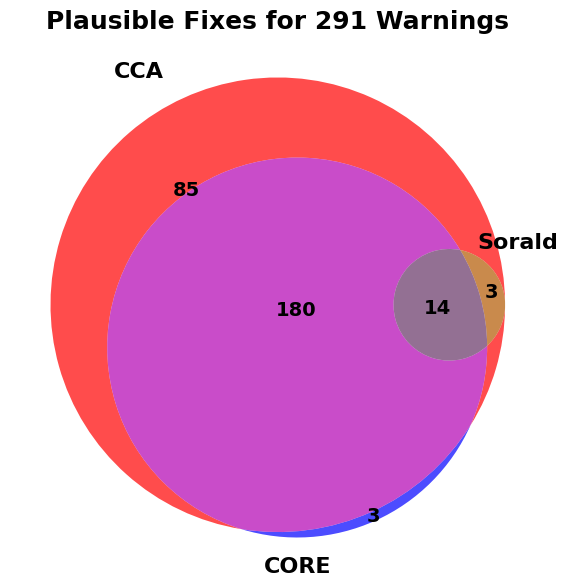

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib_venn as venn

# Venn diagram for CCA, Sorald and CORE on the 291 warnings executed for all three


evaluation_results_cca_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")

cca_plausible_all = evaluation_results_cca_df[evaluation_results_cca_df["plausibleFix"]]
cca_plausible_first_291 = cca_plausible_all[cca_plausible_all["instanceID"] <= 291]

set_of_warnings_cca_plausible_fix = set(cca_plausible_first_291["instanceID"].to_list())


evaluation_results_sorald_df = pd.read_csv("../../comparative_study/sorald_comparison/sorald_comparison_results.csv")

sorald_plausible = (
        (evaluation_results_sorald_df["soraldFixCreated"] == True) &
        (evaluation_results_sorald_df["soraldBuildSuccessful"] == True) &
        (evaluation_results_sorald_df["soraldNumberOfTargetWarningsRemoved"].fillna(0).astype(int) >= 1) &
        (evaluation_results_sorald_df["soraldNoNewWarningIntroduced"] == True) &
        (evaluation_results_sorald_df["soraldTestSuccessful"] == True)
    )
sorald_plausible_first_291 = evaluation_results_sorald_df[sorald_plausible & (evaluation_results_sorald_df["instanceID"] <= 291)]

set_of_warnings_sorald_plausible_fix = set(sorald_plausible_first_291["instanceID"].to_list())


evaluation_results_core_df = pd.read_csv("../../comparative_study/core_comparison/core_comparison_results.csv")

core_plausible_first_291 = evaluation_results_core_df[
    (evaluation_results_core_df["coreNumberBuildAndRemovedWarningAndNoNewWarningAndTest"] > 0) & 
    (evaluation_results_core_df["instanceID"] <= 291)
    ]

set_of_warnings_core_plausible_fix = set(core_plausible_first_291["instanceID"].to_list())

plt.figure(figsize=(6, 6))
venn = venn.venn3(
    [set_of_warnings_cca_plausible_fix, set_of_warnings_sorald_plausible_fix, set_of_warnings_core_plausible_fix],
    set_labels=('CCA', 'Sorald', 'CORE')
)

# Customize set labels
for label in venn.set_labels:
    label.set_fontsize(16)
    label.set_fontweight('bold')

# Customize subset labels (numbers)
for label in venn.subset_labels:
    if label:
        label.set_fontsize(14)
        label.set_fontweight('bold')
        label.set_color('black')

# Optional: Change patch colors for better contrast
colors = ['#a6cee3', '#b2df8a', '#fb9a99']
for i, patch in enumerate(venn.patches):
    if patch:
        patch.set_alpha(0.7)
        #patch.set_color(colors[i % len(colors)])

plt.title("Plausible Fixes for 291 Warnings", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig("../evaluation_results/plots/venn_diagram_cca_sorald_core.png", dpi=300)
plt.show()


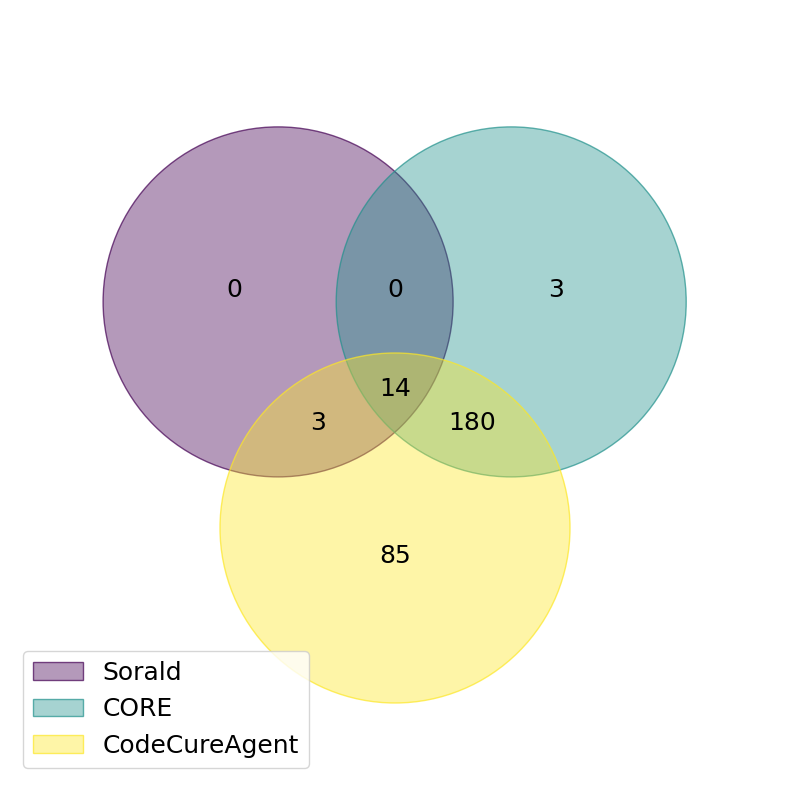

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from venn import venn

# Venn diagram for CCA, Sorald and CORE on the 291 warnings executed for all three


evaluation_results_cca_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")

cca_plausible_all = evaluation_results_cca_df[evaluation_results_cca_df["plausibleFix"]]
cca_plausible_first_291 = cca_plausible_all[cca_plausible_all["instanceID"] <= 291]

set_of_warnings_cca_plausible_fix = set(cca_plausible_first_291["instanceID"].to_list())


evaluation_results_sorald_df = pd.read_csv("../../comparative_study/sorald_comparison/sorald_comparison_results.csv")

sorald_plausible = (
        (evaluation_results_sorald_df["soraldFixCreated"] == True) &
        (evaluation_results_sorald_df["soraldBuildSuccessful"] == True) &
        (evaluation_results_sorald_df["soraldNumberOfTargetWarningsRemoved"].fillna(0).astype(int) >= 1) &
        (evaluation_results_sorald_df["soraldNoNewWarningIntroduced"] == True) &
        (evaluation_results_sorald_df["soraldTestSuccessful"] == True)
    )
sorald_plausible_first_291 = evaluation_results_sorald_df[sorald_plausible & (evaluation_results_sorald_df["instanceID"] <= 291)]

set_of_warnings_sorald_plausible_fix = set(sorald_plausible_first_291["instanceID"].to_list())


evaluation_results_core_df = pd.read_csv("../../comparative_study/core_comparison/core_comparison_results.csv")

core_plausible_first_291 = evaluation_results_core_df[
    (evaluation_results_core_df["coreNumberBuildAndRemovedWarningAndNoNewWarningAndTest"] > 0) & 
    (evaluation_results_core_df["instanceID"] <= 291)
    ]

set_of_warnings_core_plausible_fix = set(core_plausible_first_291["instanceID"].to_list())

warnings_set = {
    'Sorald': set_of_warnings_sorald_plausible_fix,
    'CORE': set_of_warnings_core_plausible_fix,
    'CodeCureAgent': set_of_warnings_cca_plausible_fix
}

venn(warnings_set, fontsize=18, legend_loc="lower left")

plt.tight_layout()

plt.savefig("../evaluation_results/plots/venn_diagram_cca_sorald_core.svg", dpi=300)
plt.show()